# <center>AI1013: Programming for AI</center>
## <center>Assignment - I</center>

### 1. Computation of avg search delays, relative entropy distance per neuron, and l_1 distance per neuron

Let's begin with importing necessary modules

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma

Importing the datasets as pandas dataframes

In [167]:
search_times_df = pd.read_csv("search-times-dataset.csv")
firing_rates_df = pd.read_csv("firing-rates-dataset.csv")

Converting the data to correct data type 

In [168]:
search_times_df[2:] = search_times_df[2:].apply(pd.to_numeric, errors = 'coerce')
firing_rates_df[2:] = firing_rates_df[2:].apply(pd.to_numeric, errors = 'coerce')

(a) Lets calculate the average search delay

In [196]:
#Array to store the avg values
average_search_delays = np.zeros(18)

#iterating through every column of the data set
for i in range(0,18):
    average_search_delays[i] = search_times_df.iloc[2:,i].mean() - 328

average_search_delays

array([ 883.77777778, 1081.40277778,  985.25      , 1009.13888889,
        275.26388889,  296.66666667,  503.31944444,  502.79166667,
        313.40277778,  307.52777778,  218.55555556,  251.95833333,
        818.33333333,  615.23611111,  309.40277778,  341.93055556,
        239.84722222,  209.38888889])

(b) Calculating relative entropy distance per neuron given by the formula
$$D_{i,j} \quad \colon = \quad \frac{1}{N} \sum_{n=1}^{N} \left [ \lambda_i(n) \log{\frac{\lambda_i(n)}{\lambda_j(n)}} - \lambda_i (n) + \lambda_j (n)\right ]$$

[0.82710247 0.91275154 0.72570649 0.65533799 1.58135601 1.74052142
 1.10761949 1.08117659 1.46193832 1.56548597 2.57335399 2.12910475
 0.69907011 0.77310702 1.49818293 1.4689169  1.64949285 2.17801864]
Slope       : 0.0019858087438862026


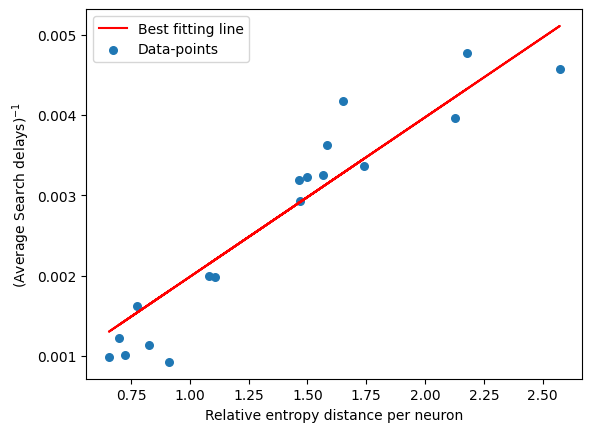

In [170]:
# array to store relative entropy distanace per neuron
relative_entropy_distances = np.zeros(18)
#The first column contains D_i_j and the second column contains D_j_i


#We will loop through each pair of columns 
for i in range(0,18, 2):
    #copying the columns
    lambda_i = firing_rates_df.iloc[2:, i].copy()
    lambda_j = firing_rates_df.iloc[2:,i+1].copy()

    #dropping the NaN values (if any)
    lambda_i = lambda_i.dropna()
    lambda_j = lambda_j.dropna()

    #resetting the indices
    lambda_i = lambda_i.reset_index(drop=True)
    lambda_j = lambda_j.reset_index(drop=True)

    #laplace smoothing to account for zero entries in the data
    epsilon = 1e-10
    lambda_i = lambda_i + epsilon
    lambda_j = lambda_j + epsilon

    
    #Now calculating the D_i_j
    for index in range(len(lambda_i)):
        relative_entropy_distances[i] += lambda_i[index] * np.log(lambda_i[index] / lambda_j[index]) - lambda_i[index] + lambda_j[index]

    #normalizing
    relative_entropy_distances[i] /= len(lambda_i)

    #Now calculating the D_j_i
    for index in range(len(lambda_i)):
        relative_entropy_distances[i+1] += lambda_j[index] * np.log(lambda_j[index] / lambda_i[index]) - lambda_j[index] + lambda_i[index]

    #normalizing
    relative_entropy_distances[i+1] /= len(lambda_i)
# Loop ends

relative_entropy_distances

#fitting a line of format y=mx to the data points
slope = (sum(relative_entropy_distances * (1/average_search_delays))) / sum(relative_entropy_distances**2)
print( f"Slope       : {slope}")

#Plotting the data-points and the fitting curve
y_fit = relative_entropy_distances * slope
plt.plot(relative_entropy_distances, y_fit, color="red", label="Best fitting line")
plt.scatter(relative_entropy_distances, 1/average_search_delays, label="Data-points", s=30)
plt.legend()
plt.xlabel("Relative entropy distance per neuron")
plt.ylabel("(Average Search delays)$^{-1}$")
plt.show()

(c) Calculating the L_1 distance per neuron given by
$$L_{i,j} \quad \colon = \quad \frac{1}{N} \sum_{n=1}^N | \lambda_i(n) - \lambda_j(n)|$$

[2.7756785  2.7756785  3.20633068 3.20633068 4.79391394 4.79391394
 3.79158273 3.79158273 4.13455124 4.13455124 4.72969894 4.72969894
 3.11108657 3.11108657 3.94509803 3.94509803 5.45929509 5.45929509]
Slope       : 0.0007000776902229354


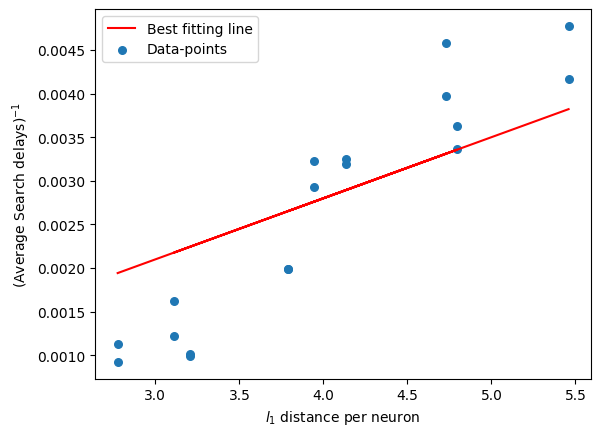

In [171]:
#Array to store L_1 distances 
L_1_distances = np.zeros(18)


#We will loop through each pair of columns 
for i in range(0,18, 2):
    #copying the columns
    lambda_i = firing_rates_df.iloc[2:, i].copy()
    lambda_j = firing_rates_df.iloc[2:,i+1].copy()

    #dropping the NaN values (if any)
    lambda_i = lambda_i.dropna()
    lambda_j = lambda_j.dropna()

    #resetting the indices
    lambda_i = lambda_i.reset_index(drop=True)
    lambda_j = lambda_j.reset_index(drop=True)

    
    #Now calculating the L_1_i_j (and alos L_1_j_i)
    for index in range(len(lambda_i)):
        L_1_distances[i] += abs(lambda_i[index] - lambda_j[index])

    #normalizing
    L_1_distances[i] /= len(lambda_i)

    #L_1_i_j = L_1_j_i so
    L_1_distances[i+1] = L_1_distances[i]
    
# Loop ends

print(L_1_distances)

#fitting a line y=mx to the data points
slope = (sum(L_1_distances * (1/average_search_delays))) / sum(L_1_distances**2)
print( f"Slope       : {slope}")

#Plotting the data-points and the fitting curve
y_fit = L_1_distances * slope
plt.plot(L_1_distances, y_fit, color="red", label="Best fitting line")
plt.scatter(L_1_distances, 1/average_search_delays, label="Data-points", s=30)
plt.legend()
plt.xlabel("$l_1$ distance per neuron")
plt.ylabel("(Average Search delays)$^{-1}$")
plt.show()    

It is quite visible from the two plots that the line in the case of Relative entropy distances is a beter fit.

Let's Now try to fit a gamma distribution to the search delays data.

For part (a), first we will start by randomly selecting half of the columns.
For selection of columns, I am using `np.random` with seed = 15 (my roll number) for easy reproduction of the outputs.

In [172]:
# np.random.seed(15)
selected_indices = np.random.choice(18, 9,replace=False)
selected_indices.sort()
print(f"Selected indices are {selected_indices}")

Selected indices are [ 0  2  3  6  7 12 13 15 16]


Now, We will calculate and store the mean and standard deviation of each column

In [173]:
mean_search_delays = np.zeros(9)
std_search_delays = np.zeros(9)

for i in range(0,9):
    #getting the column
    column = search_times_df.iloc[2:, selected_indices[i]].copy()

    #resetting the indices of the column
    column = column.reset_index(drop=True)



    column = column.dropna()
    column = column.to_numpy()
    column = column - 328
    column = list(column)

    mean_search_delays[i] = np.mean(column)
    std_search_delays[i] = np.std(column)

Plotting the graphs and calculating the best fit slope

0.6196900797771787


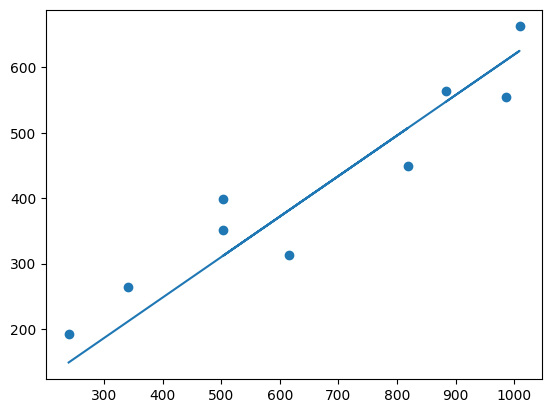

In [174]:
slope = (sum(mean_search_delays * std_search_delays) / sum(mean_search_delays**2))
print(slope)

plt.plot(mean_search_delays, mean_search_delays*slope )
plt.scatter(mean_search_delays, std_search_delays)

For gamma distribution, we have $\mu = a/b$ and $\sigma = \sqrt{a}/b$, so the slope $m$ of the above graph is $\sigma / \mu = 1/\sqrt{a}$. So, $a = 1/m^2$. Using this relation, we estimate the shape parameter $a$

In [175]:
shape_parameter = (1/slope)**2
print(f"The shape parameter a = {shape_parameter}")

The shape parameter a = 2.604059554547918


(b) Now to estimate the rate parameter $b$, we will collect half samples from each of the unused column randommly and use them to estimate.



In [176]:
#list consisting of the remaining indices
remaining_indices = [index for index in range(0,18) if index not in selected_indices]

Now we will make an array of samples by taking half values from each of the columns.

In [177]:
#list to store the samples
samples_selected = [] #will be used for (b) to estimate rate parameter
samples_remaining =[] #will be ued for (c) part

for index in remaining_indices:
    #getting the column
    column = search_times_df.iloc[2:,index].copy().to_numpy()

    #subtracting the mean reaction time
    column = column - 328

    #shuffling the columns with a seed (for easy reproducability)
    np.random.seed(15+i)
    np.random.shuffle(column)

    mid_index = len(column)//2

    #selecting the first half samples, and putting the remaining ones for part (c)
    samples_selected.extend(column[:mid_index]) 
    samples_remaining.extend(column[mid_index:])
    
samples_selected = np.array(samples_selected)
samples_remaining = np.array(samples_remaining)

Now, we know that $\mu = a/b$ and $\sigma = \sqrt{a} / b \implies \sigma^2 = a/b^2$, <br>
So, we get $b = \mu / \sigma^2$.<br>
Using this relation to calculate the rate parameter

In [178]:
mean = np.mean(samples_selected)
variance = np.var(samples_selected)

rate_parameter = shape_parameter / mean
print(f"The estimated rate parameter b = {rate_parameter}")

The estimated rate parameter b = 0.0073328289212022035


(c) Now we will get the array `search_delays`

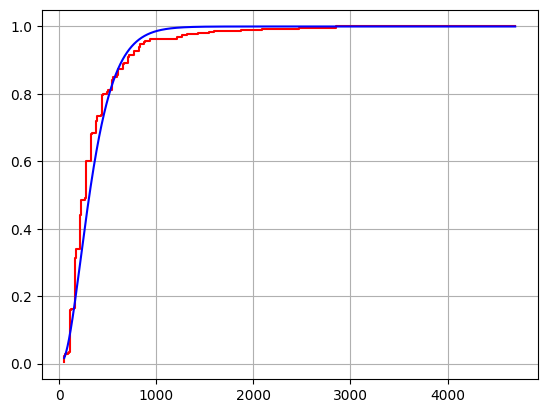

(1.7720727834046521, 0, np.float64(208.8594785704966))


In [191]:
search_delays = samples_remaining #the remaining samples to be used now


#now plotting the empirical CDF
search_delays = np.sort(search_delays)
y_values = np.arange(1, len(search_delays)+1) / len(search_delays)

#now plotting the Gamma(a,b) CDF
from scipy.stats import gamma
x_cdf = np.linspace(search_delays[0],search_delays[-1],5000)
cdf = gamma.cdf(x_cdf,shape_parameter,scale = 1/rate_parameter)
plt.step(search_delays, y_values, color = "red")
plt.plot(x_cdf,cdf, color = "blue")
plt.grid()
plt.show()
print(gamma.fit(search_delays, floc=0))

The graph clearly shows that the data of the search delays fit very well to a gamma distribution. <br>
Now lets calculate and print the <i>Kolmogorov-Smirnov</i> test statistic given as 
$$\text{KS}(F,G) = \max_x |F(x)-G(x)|$$

In [195]:
KS_test_stat = 0

#as indicated, looping for all x in search_delays
for i in range(len(search_delays)):
    x = search_delays[i]

    #F(x) is simply the y_values at this point
    F = y_values[i]

    #G(x) can be calculated using the scipy.stats import
    G = gamma.cdf(x, shape_parameter, scale = 1/rate_parameter)

    #updating max_diff (if bigger difference is found)
    KS_test_stat = max(KS_test_stat, abs(F-G))
print(f"The Kolmogorov-Smirnov test statistic for the search delays and theoretical Gamma distribution = {KS_test_stat}")

The Kolmogorov-Smirnov test statistic for the search delays and theoretical Gamma distribution = 0.16536078563807333
